# GlycoPilot - Baseline IA
## Prédiction de glycémie avec XGBoost et ARIMA

**Objectif MVP** : Créer une baseline pour la prédiction de glycémie à 30 minutes

**Dataset** : BIG IDEAS Lab - Glycemic Variability and Wearable Device Data
- 36,610 mesures
- 16 participants
- 164 jours de données
- Features : glycémie, HR, température, HRV, lags, rolling stats

**Modèles** :
1. XGBoost (recommandé MVP)
2. ARIMA (baseline statistique)

**Métriques** : MAE, RMSE, R², détection hypo/hyperglycémie

## 1. Installation des dépendances

In [1]:
# Installation des packages nécessaires
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn statsmodels

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Time series
from statsmodels.tsa.arima.model import ARIMA

# Config plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 3. Chargement et exploration des données

In [3]:
# Charger le dataset
df = pd.read_csv('../data/BIG-IDEAs-Lab-Glycemic-Variability-and-Wearable-Device-Data.csv')

# Convertir datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print("📊 Dimensions du dataset")
print(f"Lignes : {len(df):,}")
print(f"Colonnes : {len(df.columns)}")
print(f"\n🧪 Participants : {df['participant_id'].nunique()}")
print(f"📅 Période : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"⏱️  Durée : {(df['datetime'].max() - df['datetime'].min()).days} jours")

df.head()

📊 Dimensions du dataset
Lignes : 36,610
Colonnes : 22

🧪 Participants : 16
📅 Période : 2020-02-13 18:23:32 → 2020-07-27 10:08:47
⏱️  Durée : 164 jours


,datetime,glucose,hr_mean_5min,hr_std_5min,temp_mean_5min,temp_std_5min,hrv_rmssd_5min,glucose_target_30min,glucose_lag_5min,glucose_lag_15min,...,glucose_rolling_mean_15min,glucose_rolling_std_15min,glucose_rolling_mean_30min,glucose_rolling_std_30min,glucose_rolling_mean_60min,glucose_rolling_std_60min,glucose_roc,participant_id,hba1c,gender_is_female
0,2020-02-13 18:23:32,105.0,66.895067,7.502622,34.834900,0.034862,0.087736,141.0,86.0,60.0,...,87.000000,17.521415,73.833333,18.236410,68.083333,13.996482,19.0,1,5.5,1
1,2020-02-13 18:28:31,118.0,64.442400,3.180035,34.907467,0.040484,0.063070,132.0,105.0,70.0,...,103.000000,16.093477,83.000000,24.462216,73.000000,19.711556,13.0,1,5.5,1
2,2020-02-13 18:33:31,127.0,63.320100,1.329265,34.925433,0.031575,0.060080,122.0,118.0,86.0,...,116.666667,11.060440,94.333333,26.763159,78.750000,24.435909,9.0,1,5.5,1
3,2020-02-13 18:38:32,133.0,83.173967,13.486612,35.018633,0.069756,0.081167,116.0,127.0,105.0,...,126.000000,7.549834,106.500000,24.533650,84.916667,28.066345,6.0,1,5.5,1
4,2020-02-13 18:43:32,139.0,93.485867,7.909730,34.975033,0.134957,0.071124,114.0,133.0,118.0,...,133.000000,6.000000,118.000000,19.697716,91.250000,31.083831,6.0,1,5.5,1


In [4]:
# Statistiques descriptives
print("\n📈 Statistiques de la glycémie")
print(df['glucose'].describe())

print("\n🎯 Distribution hypo/normal/hyper")
hypo = (df['glucose'] < 70).sum()
normal = ((df['glucose'] >= 70) & (df['glucose'] <= 180)).sum()
hyper = (df['glucose'] > 180).sum()
total = len(df)

print(f"Hypoglycémie (<70 mg/dL) : {hypo:,} ({hypo/total*100:.1f}%)")
print(f"Normal (70-180 mg/dL) : {normal:,} ({normal/total*100:.1f}%)")
print(f"Hyperglycémie (>180 mg/dL) : {hyper:,} ({hyper/total*100:.1f}%)")


📈 Statistiques de la glycémie
count    36610.000000
mean       114.457252
std         23.080571
min         40.000000
25%         99.000000
50%        111.000000
75%        125.000000
max        261.000000
Name: glucose, dtype: float64

🎯 Distribution hypo/normal/hyper
Hypoglycémie (<70 mg/dL) : 201 (0.5%)
Normal (70-180 mg/dL) : 35,756 (97.7%)
Hyperglycémie (>180 mg/dL) : 653 (1.8%)


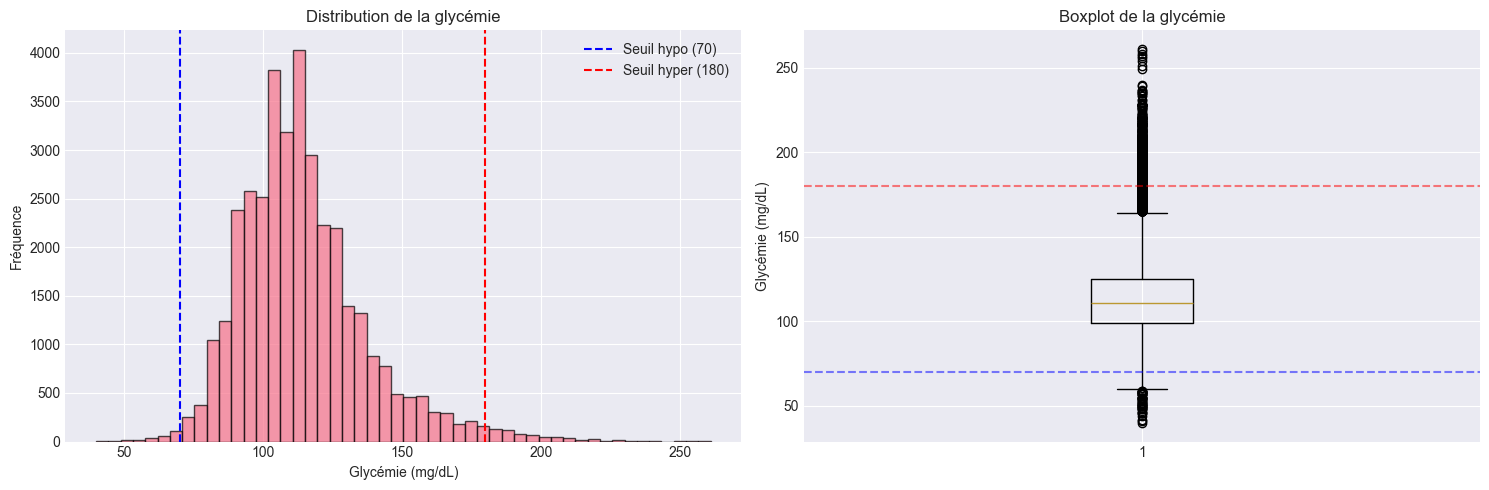

In [5]:
# Visualisation de la distribution de la glycémie
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
axes[0].hist(df['glucose'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(70, color='blue', linestyle='--', label='Seuil hypo (70)')
axes[0].axvline(180, color='red', linestyle='--', label='Seuil hyper (180)')
axes[0].set_xlabel('Glycémie (mg/dL)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la glycémie')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['glucose'])
axes[1].set_ylabel('Glycémie (mg/dL)')
axes[1].set_title('Boxplot de la glycémie')
axes[1].axhline(70, color='blue', linestyle='--', alpha=0.5)
axes[1].axhline(180, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

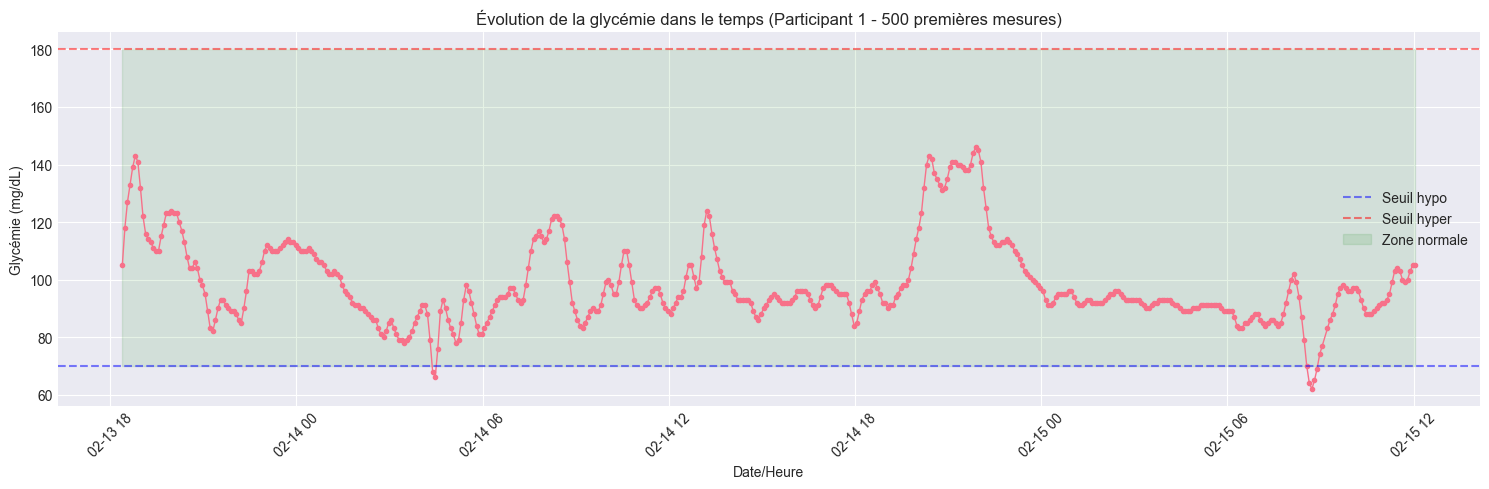

In [6]:
# Visualisation temporelle pour un participant
participant_sample = df[df['participant_id'] == 1].head(500)

plt.figure(figsize=(15, 5))
plt.plot(participant_sample['datetime'], participant_sample['glucose'], marker='o', markersize=3, linewidth=1)
plt.axhline(70, color='blue', linestyle='--', alpha=0.5, label='Seuil hypo')
plt.axhline(180, color='red', linestyle='--', alpha=0.5, label='Seuil hyper')
plt.fill_between(participant_sample['datetime'], 70, 180, alpha=0.1, color='green', label='Zone normale')
plt.xlabel('Date/Heure')
plt.ylabel('Glycémie (mg/dL)')
plt.title('Évolution de la glycémie dans le temps (Participant 1 - 500 premières mesures)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

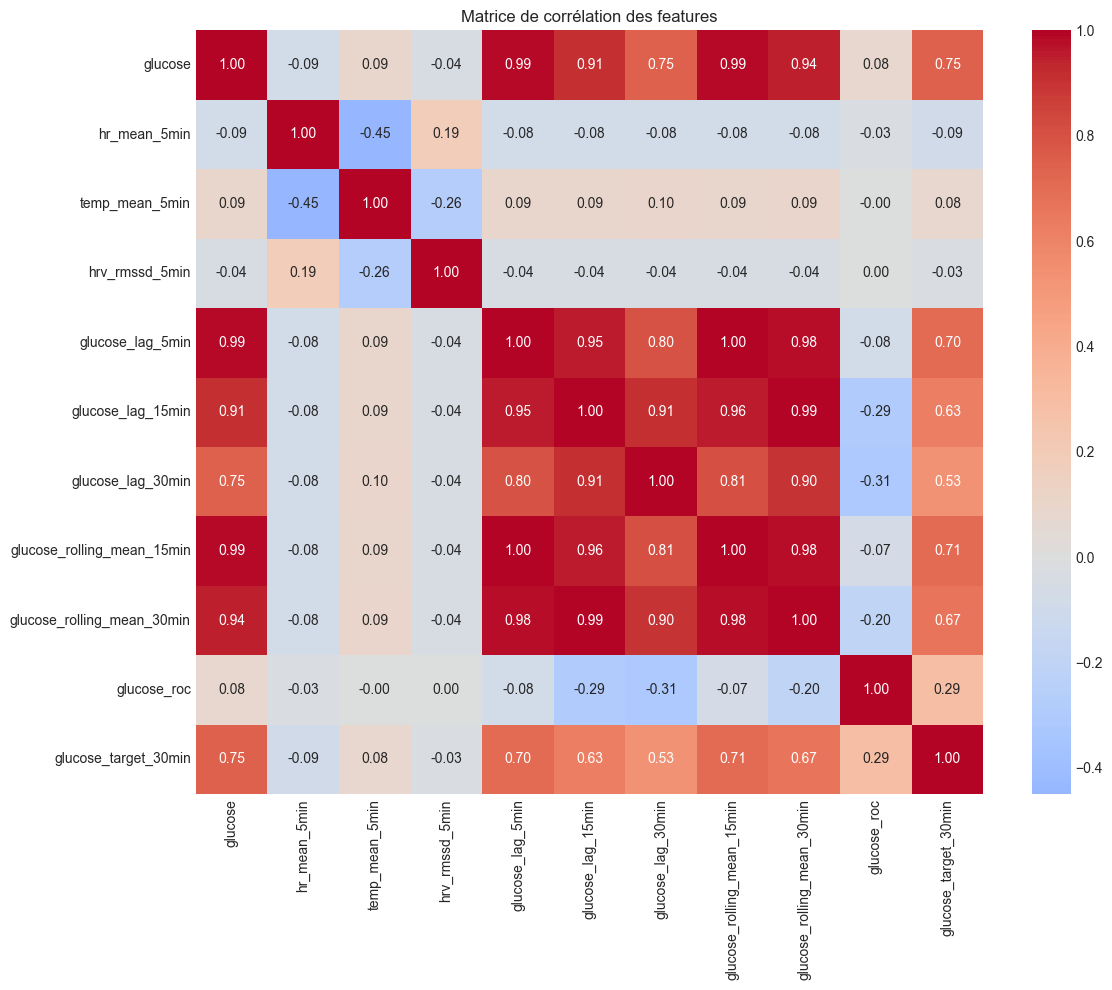


🔍 Corrélation avec la target (glucose_target_30min) :
glucose_target_30min          1.000000
glucose                       0.749940
glucose_rolling_mean_15min    0.711159
glucose_lag_5min              0.703900
glucose_rolling_mean_30min    0.668517
glucose_lag_15min             0.625161
glucose_lag_30min             0.534671
glucose_roc                   0.287866
temp_mean_5min                0.077875
hrv_rmssd_5min               -0.026493
hr_mean_5min                 -0.090989
Name: glucose_target_30min, dtype: float64


In [7]:
# Matrice de corrélation des features
# Sélection des colonnes numériques pertinentes
feature_cols = [
    'glucose', 'hr_mean_5min', 'temp_mean_5min', 'hrv_rmssd_5min',
    'glucose_lag_5min', 'glucose_lag_15min', 'glucose_lag_30min',
    'glucose_rolling_mean_15min', 'glucose_rolling_mean_30min',
    'glucose_roc', 'glucose_target_30min'
]

plt.figure(figsize=(12, 10))
correlation_matrix = df[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

print("\n🔍 Corrélation avec la target (glucose_target_30min) :")
target_corr = correlation_matrix['glucose_target_30min'].sort_values(ascending=False)
print(target_corr)

## 4. Préparation des données

In [8]:
# Définir les features et la target
# La target est déjà créée : glucose_target_30min (glycémie à +30 minutes)

# Features à utiliser
feature_columns = [
    'glucose',                    # Glycémie actuelle
    'hr_mean_5min',               # Fréquence cardiaque moyenne
    'hr_std_5min',                # Écart-type FC
    'temp_mean_5min',             # Température moyenne
    'temp_std_5min',              # Écart-type température
    'hrv_rmssd_5min',             # Variabilité cardiaque
    'glucose_lag_5min',           # Glycémie il y a 5 min
    'glucose_lag_15min',          # Glycémie il y a 15 min
    'glucose_lag_30min',          # Glycémie il y a 30 min
    'glucose_lag_60min',          # Glycémie il y a 60 min
    'glucose_rolling_mean_15min', # Moyenne mobile 15min
    'glucose_rolling_std_15min',  # Écart-type 15min
    'glucose_rolling_mean_30min', # Moyenne mobile 30min
    'glucose_rolling_std_30min',  # Écart-type 30min
    'glucose_rolling_mean_60min', # Moyenne mobile 60min
    'glucose_rolling_std_60min',  # Écart-type 60min
    'glucose_roc',                # Rate of change
    'hba1c',                      # HbA1c du participant
    'gender_is_female'            # Genre
]

target_column = 'glucose_target_30min'

# Vérifier qu'il n'y a pas de valeurs manquantes
print("⚠️  Valeurs manquantes :")
print(df[feature_columns + [target_column]].isnull().sum())

# Supprimer les lignes avec des valeurs manquantes si nécessaire
df_clean = df.dropna(subset=feature_columns + [target_column])
print(f"\n✅ Dataset nettoyé : {len(df_clean):,} lignes")

⚠️  Valeurs manquantes :
glucose                       0
hr_mean_5min                  0
hr_std_5min                   0
temp_mean_5min                0
temp_std_5min                 0
hrv_rmssd_5min                0
glucose_lag_5min              0
glucose_lag_15min             0
glucose_lag_30min             0
glucose_lag_60min             0
glucose_rolling_mean_15min    0
glucose_rolling_std_15min     0
glucose_rolling_mean_30min    0
glucose_rolling_std_30min     0
glucose_rolling_mean_60min    0
glucose_rolling_std_60min     0
glucose_roc                   0
hba1c                         0
gender_is_female              0
glucose_target_30min          0
dtype: int64

✅ Dataset nettoyé : 36,610 lignes


In [9]:
# Split train/test (80/20)
# Important : split temporel pour respecter la nature séquentielle des données

# Option 1 : Split temporel strict (recommandé pour time series)
split_date = df_clean['datetime'].quantile(0.8)
train_df = df_clean[df_clean['datetime'] < split_date]
test_df = df_clean[df_clean['datetime'] >= split_date]

X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("📊 Split temporel :")
print(f"Train : {len(X_train):,} samples ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"Test : {len(X_test):,} samples ({len(X_test)/len(df_clean)*100:.1f}%)")
print(f"\nDate de split : {split_date}")

📊 Split temporel :
Train : 29,288 samples (80.0%)
Test : 7,322 samples (20.0%)

Date de split : 2020-05-31 08:52:48


## 5. Modèle 1 : XGBoost (MVP recommandé)

In [10]:
# Entraînement XGBoost
print("🚀 Entraînement du modèle XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("✅ Modèle entraîné !")

🚀 Entraînement du modèle XGBoost...
✅ Modèle entraîné !


In [11]:
# Prédictions
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

# Métriques
def calculate_metrics(y_true, y_pred, dataset_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n📊 Métriques {dataset_name}")
    print(f"MAE  : {mae:.2f} mg/dL")
    print(f"RMSE : {rmse:.2f} mg/dL")
    print(f"R²   : {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("="*60)
print("🎯 RÉSULTATS XGBoost")
print("="*60)

train_metrics_xgb = calculate_metrics(y_train, y_pred_train_xgb, "TRAIN")
test_metrics_xgb = calculate_metrics(y_test, y_pred_test_xgb, "TEST")

🎯 RÉSULTATS XGBoost

📊 Métriques TRAIN
MAE  : 6.72 mg/dL
RMSE : 9.70 mg/dL
R²   : 0.8312

📊 Métriques TEST
MAE  : 10.26 mg/dL
RMSE : 14.85 mg/dL
R²   : 0.4959


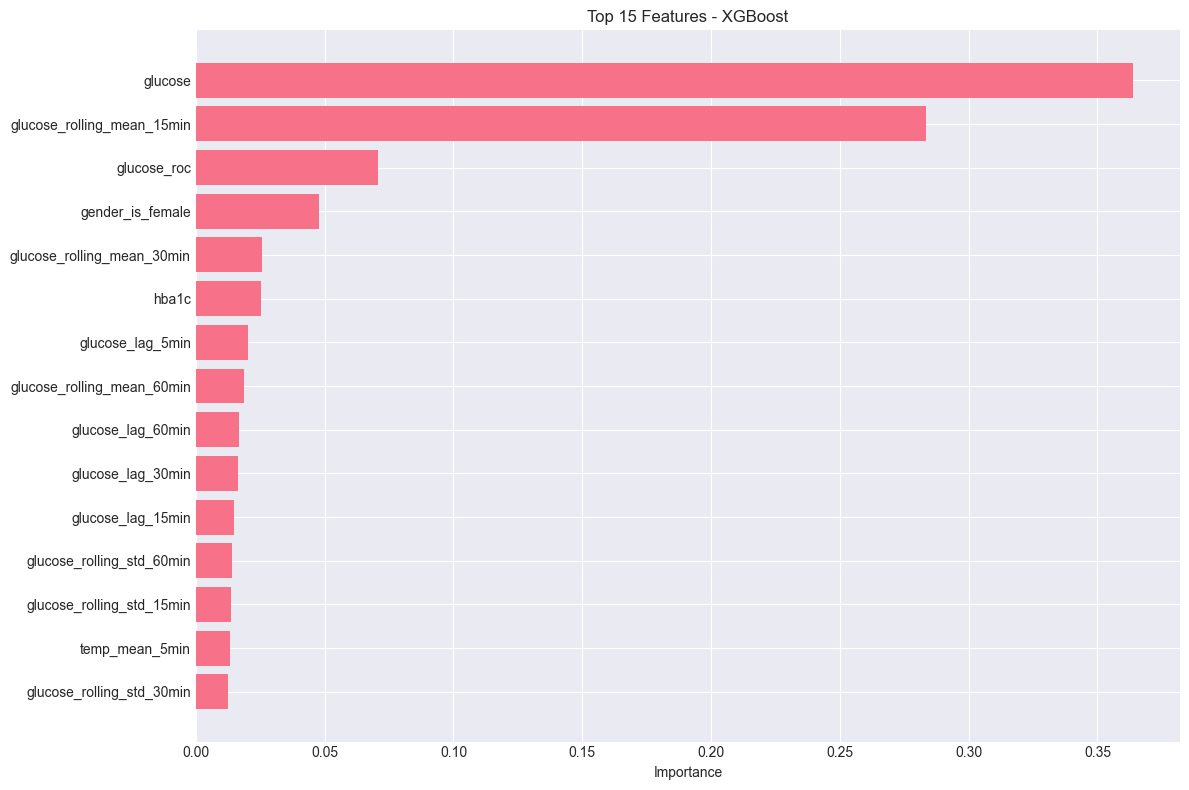


🔝 Top 10 features les plus importantes :
                       feature  importance
0                      glucose    0.363853
10  glucose_rolling_mean_15min    0.283272
16                 glucose_roc    0.070831
18            gender_is_female    0.047684
12  glucose_rolling_mean_30min    0.025565
17                       hba1c    0.025102
6             glucose_lag_5min    0.020245
14  glucose_rolling_mean_60min    0.018539
9            glucose_lag_60min    0.016807
8            glucose_lag_30min    0.016457


In [12]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n🔝 Top 10 features les plus importantes :")
print(feature_importance.head(10))

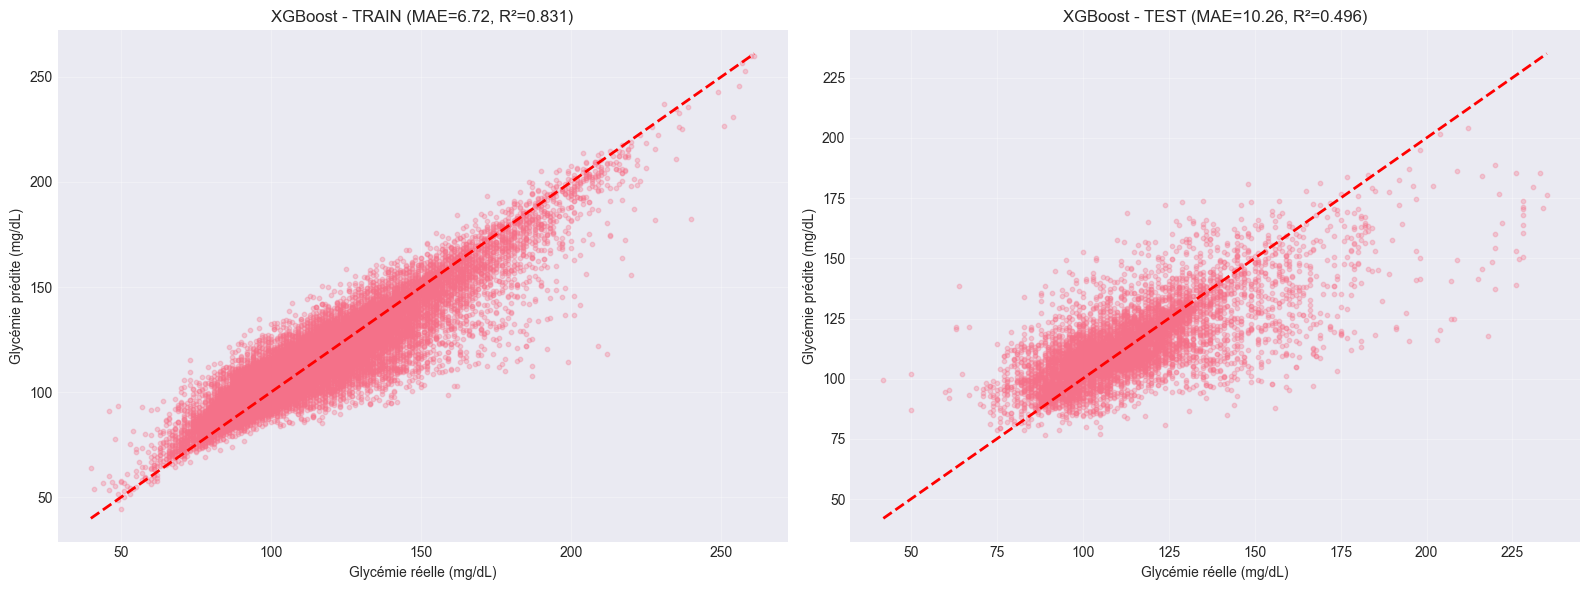

In [13]:
# Visualisation des prédictions vs réalité
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
axes[0].scatter(y_train, y_pred_train_xgb, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Glycémie réelle (mg/dL)')
axes[0].set_ylabel('Glycémie prédite (mg/dL)')
axes[0].set_title(f'XGBoost - TRAIN (MAE={train_metrics_xgb["MAE"]:.2f}, R²={train_metrics_xgb["R2"]:.3f})')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, y_pred_test_xgb, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Glycémie réelle (mg/dL)')
axes[1].set_ylabel('Glycémie prédite (mg/dL)')
axes[1].set_title(f'XGBoost - TEST (MAE={test_metrics_xgb["MAE"]:.2f}, R²={test_metrics_xgb["R2"]:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

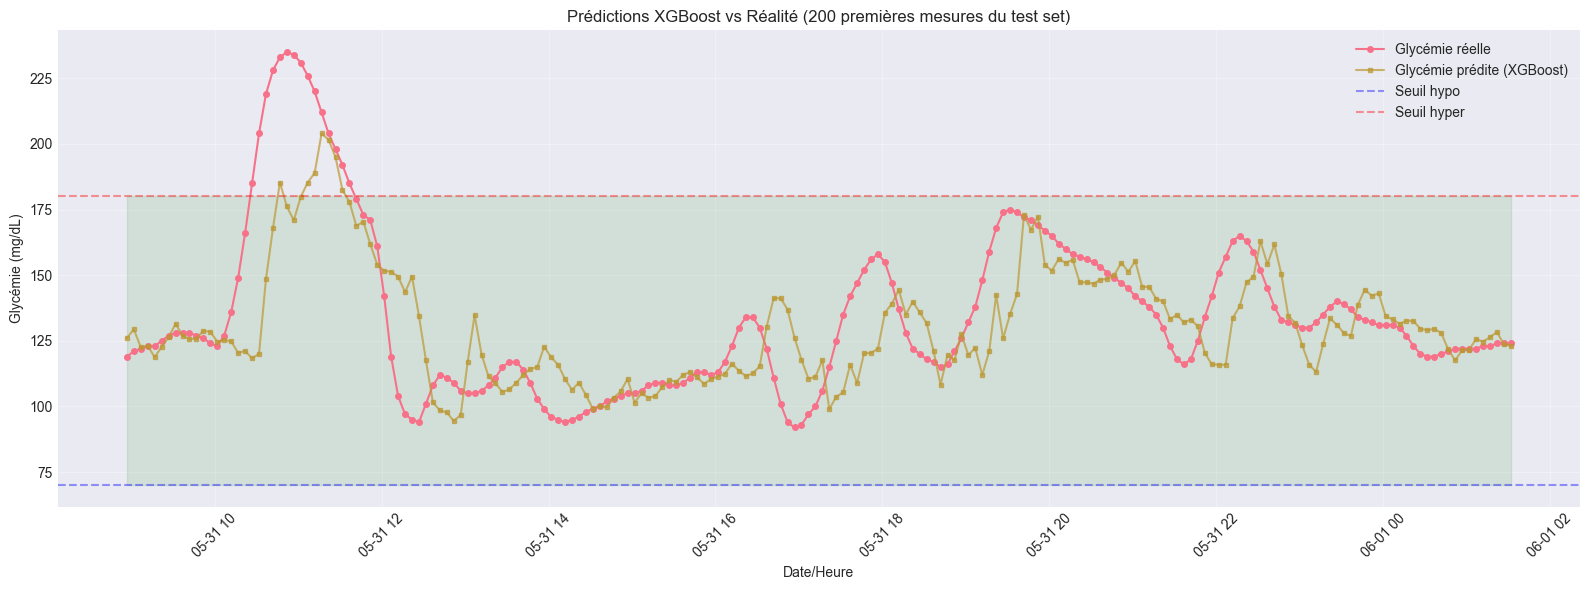

In [14]:
# Visualisation temporelle des prédictions (échantillon)
sample_size = 200
test_sample = test_df.head(sample_size).copy()
test_sample['predicted'] = y_pred_test_xgb[:sample_size]

plt.figure(figsize=(16, 6))
plt.plot(test_sample['datetime'], test_sample[target_column], label='Glycémie réelle', marker='o', markersize=4, linewidth=1.5)
plt.plot(test_sample['datetime'], test_sample['predicted'], label='Glycémie prédite (XGBoost)', marker='s', markersize=3, linewidth=1.5, alpha=0.7)
plt.axhline(70, color='blue', linestyle='--', alpha=0.4, label='Seuil hypo')
plt.axhline(180, color='red', linestyle='--', alpha=0.4, label='Seuil hyper')
plt.fill_between(test_sample['datetime'], 70, 180, alpha=0.1, color='green')
plt.xlabel('Date/Heure')
plt.ylabel('Glycémie (mg/dL)')
plt.title(f'Prédictions XGBoost vs Réalité ({sample_size} premières mesures du test set)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Modèle 2 : ARIMA (baseline statistique)

In [15]:
# ARIMA sur un participant (modèle univarié)
# Pour simplifier, on prend un seul participant
participant_id = 1
participant_data = df_clean[df_clean['participant_id'] == participant_id].copy()

# Split temporel 80/20
split_idx = int(len(participant_data) * 0.8)
train_arima = participant_data['glucose'][:split_idx]
test_arima = participant_data['glucose'][split_idx:]

print(f"🧪 ARIMA sur participant {participant_id}")
print(f"Train : {len(train_arima)} points")
print(f"Test : {len(test_arima)} points")

🧪 ARIMA sur participant 1
Train : 2034 points
Test : 509 points


In [16]:
# Entraînement ARIMA(1,0,1) - simple baseline
print("\n🚀 Entraînement ARIMA...")

arima_model = ARIMA(train_arima, order=(1, 0, 1))
arima_fitted = arima_model.fit()

print("✅ Modèle ARIMA entraîné !")
print(arima_fitted.summary())


🚀 Entraînement ARIMA...
✅ Modèle ARIMA entraîné !
                               SARIMAX Results                                
Dep. Variable:                glucose   No. Observations:                 2034
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4522.370
Date:                Thu, 16 Apr 2026   AIC                           9052.740
Time:                        13:53:44   BIC                           9075.211
Sample:                             0   HQIC                          9060.984
                               - 2034                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        106.3020      3.049     34.860      0.000     100.325     112.279
ar.L1          0.9716      0.005    205.645      0.000       0.962       0.981
m

In [17]:
# Prédictions ARIMA
# Pour prédire à 30min (6 pas de temps à 5min), on fait des prédictions rolling
# Simplifié : prédiction 1-step ahead

predictions_arima = []
history = list(train_arima)

for t in range(len(test_arima)):
    model = ARIMA(history, order=(1, 0, 1))
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)[0]
    predictions_arima.append(yhat)
    history.append(test_arima.iloc[t])
    
    if (t+1) % 100 == 0:
        print(f"Progression : {t+1}/{len(test_arima)}")

predictions_arima = np.array(predictions_arima)
print("\n✅ Prédictions terminées !")

Progression : 100/509
Progression : 200/509
Progression : 300/509
Progression : 400/509
Progression : 500/509

✅ Prédictions terminées !


In [18]:
# Métriques ARIMA
mae_arima = mean_absolute_error(test_arima, predictions_arima)
rmse_arima = np.sqrt(mean_squared_error(test_arima, predictions_arima))
r2_arima = r2_score(test_arima, predictions_arima)

print("="*60)
print(f"🎯 RÉSULTATS ARIMA (Participant {participant_id})")
print("="*60)
print(f"MAE  : {mae_arima:.2f} mg/dL")
print(f"RMSE : {rmse_arima:.2f} mg/dL")
print(f"R²   : {r2_arima:.4f}")

🎯 RÉSULTATS ARIMA (Participant 1)
MAE  : 1.51 mg/dL
RMSE : 2.12 mg/dL
R²   : 0.9748


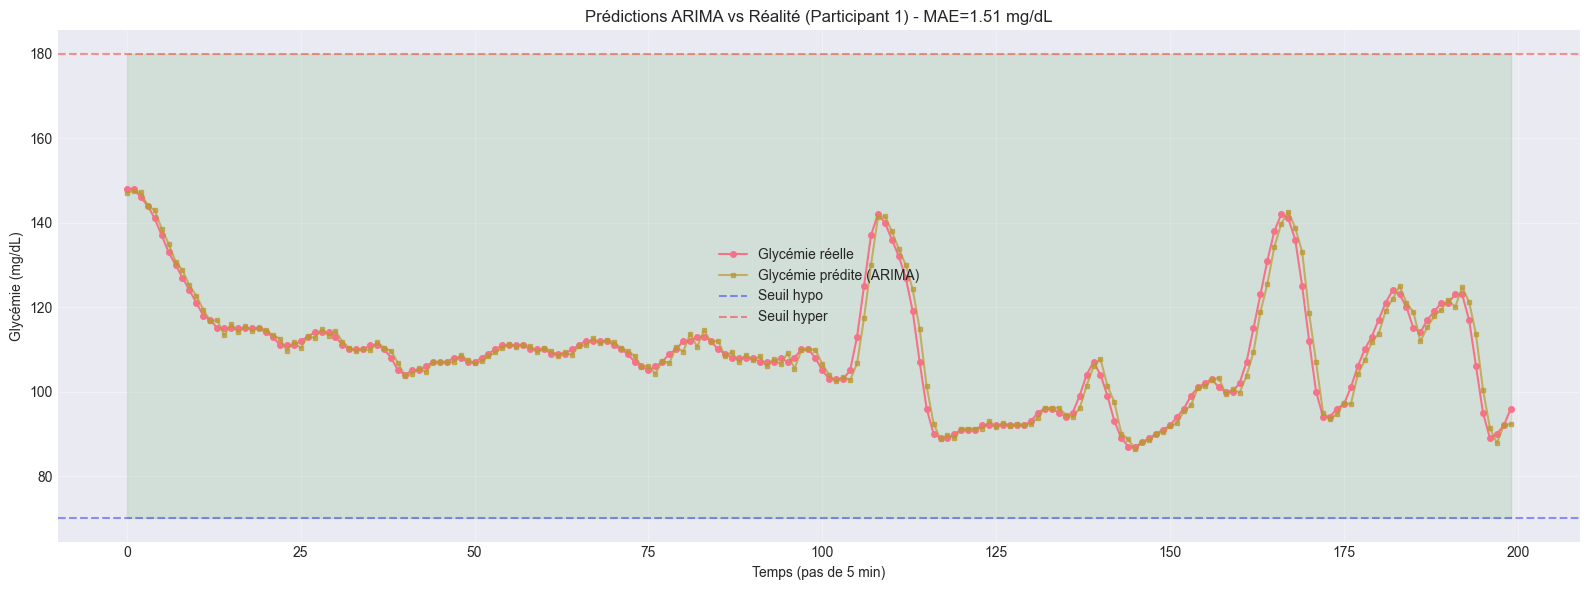

In [19]:
# Visualisation ARIMA
plt.figure(figsize=(16, 6))
sample_size_arima = min(200, len(test_arima))
plt.plot(range(sample_size_arima), test_arima.iloc[:sample_size_arima].values, label='Glycémie réelle', marker='o', markersize=4)
plt.plot(range(sample_size_arima), predictions_arima[:sample_size_arima], label='Glycémie prédite (ARIMA)', marker='s', markersize=3, alpha=0.7)
plt.axhline(70, color='blue', linestyle='--', alpha=0.4, label='Seuil hypo')
plt.axhline(180, color='red', linestyle='--', alpha=0.4, label='Seuil hyper')
plt.fill_between(range(sample_size_arima), 70, 180, alpha=0.1, color='green')
plt.xlabel('Temps (pas de 5 min)')
plt.ylabel('Glycémie (mg/dL)')
plt.title(f'Prédictions ARIMA vs Réalité (Participant {participant_id}) - MAE={mae_arima:.2f} mg/dL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Détection d'alertes hypo/hyperglycémie

In [20]:
# Fonction de détection d'alertes
def detect_alerts(y_true, y_pred, threshold_hypo=70, threshold_hyper=180):
    """
    Détecte les alertes hypo/hyperglycémie
    """
    # Classification
    true_hypo = y_true < threshold_hypo
    true_hyper = y_true > threshold_hyper
    pred_hypo = y_pred < threshold_hypo
    pred_hyper = y_pred > threshold_hyper
    
    # Métriques hypo
    tp_hypo = ((true_hypo) & (pred_hypo)).sum()
    fp_hypo = ((~true_hypo) & (pred_hypo)).sum()
    fn_hypo = ((true_hypo) & (~pred_hypo)).sum()
    
    precision_hypo = tp_hypo / (tp_hypo + fp_hypo) if (tp_hypo + fp_hypo) > 0 else 0
    recall_hypo = tp_hypo / (tp_hypo + fn_hypo) if (tp_hypo + fn_hypo) > 0 else 0
    f1_hypo = 2 * (precision_hypo * recall_hypo) / (precision_hypo + recall_hypo) if (precision_hypo + recall_hypo) > 0 else 0
    
    # Métriques hyper
    tp_hyper = ((true_hyper) & (pred_hyper)).sum()
    fp_hyper = ((~true_hyper) & (pred_hyper)).sum()
    fn_hyper = ((true_hyper) & (~pred_hyper)).sum()
    
    precision_hyper = tp_hyper / (tp_hyper + fp_hyper) if (tp_hyper + fp_hyper) > 0 else 0
    recall_hyper = tp_hyper / (tp_hyper + fn_hyper) if (tp_hyper + fn_hyper) > 0 else 0
    f1_hyper = 2 * (precision_hyper * recall_hyper) / (precision_hyper + recall_hyper) if (precision_hyper + recall_hyper) > 0 else 0
    
    return {
        'hypo': {
            'precision': precision_hypo,
            'recall': recall_hypo,
            'f1': f1_hypo,
            'true_events': true_hypo.sum(),
            'detected': tp_hypo
        },
        'hyper': {
            'precision': precision_hyper,
            'recall': recall_hyper,
            'f1': f1_hyper,
            'true_events': true_hyper.sum(),
            'detected': tp_hyper
        }
    }

# Détection avec XGBoost
alerts_xgb = detect_alerts(y_test.values, y_pred_test_xgb)

print("="*60)
print("🚨 DÉTECTION D'ALERTES - XGBoost")
print("="*60)
print("\n🔵 HYPOGLYCÉMIE (<70 mg/dL)")
print(f"Événements réels : {alerts_xgb['hypo']['true_events']}")
print(f"Détectés : {alerts_xgb['hypo']['detected']}")
print(f"Precision : {alerts_xgb['hypo']['precision']:.3f}")
print(f"Recall : {alerts_xgb['hypo']['recall']:.3f}")
print(f"F1-Score : {alerts_xgb['hypo']['f1']:.3f}")

print("\n🔴 HYPERGLYCÉMIE (>180 mg/dL)")
print(f"Événements réels : {alerts_xgb['hyper']['true_events']}")
print(f"Détectés : {alerts_xgb['hyper']['detected']}")
print(f"Precision : {alerts_xgb['hyper']['precision']:.3f}")
print(f"Recall : {alerts_xgb['hyper']['recall']:.3f}")
print(f"F1-Score : {alerts_xgb['hyper']['f1']:.3f}")

🚨 DÉTECTION D'ALERTES - XGBoost

🔵 HYPOGLYCÉMIE (<70 mg/dL)
Événements réels : 13
Détectés : 0
Precision : 0.000
Recall : 0.000
F1-Score : 0.000

🔴 HYPERGLYCÉMIE (>180 mg/dL)
Événements réels : 81
Détectés : 13
Precision : 0.812
Recall : 0.160
F1-Score : 0.268


## 8. Comparaison des modèles

In [21]:
# Tableau comparatif
comparison = pd.DataFrame({
    'Modèle': ['XGBoost', 'ARIMA'],
    'MAE (mg/dL)': [test_metrics_xgb['MAE'], mae_arima],
    'RMSE (mg/dL)': [test_metrics_xgb['RMSE'], rmse_arima],
    'R²': [test_metrics_xgb['R2'], r2_arima],
    'Features': ['Multivariées (19)', 'Univariée (glucose seul)'],
    'Complexité': ['Moyenne', 'Faible']
})

print("="*80)
print("📊 COMPARAISON DES MODÈLES")
print("="*80)
print(comparison.to_string(index=False))

print("\n✅ RECOMMANDATION MVP : XGBoost")
print("Raisons :")
print("- Meilleure performance (MAE plus faible)")
print("- Utilise les données du wearable (HR, température, HRV)")
print("- Plus robuste pour la détection d'alertes")
print("- Scalable pour tous les participants")

📊 COMPARAISON DES MODÈLES
 Modèle  MAE (mg/dL)  RMSE (mg/dL)      R²                 Features Complexité
XGBoost    10.262241     14.846370 0.49587        Multivariées (19)    Moyenne
  ARIMA     1.505291      2.115666 0.97484 Univariée (glucose seul)     Faible

✅ RECOMMANDATION MVP : XGBoost
Raisons :
- Meilleure performance (MAE plus faible)
- Utilise les données du wearable (HR, température, HRV)
- Plus robuste pour la détection d'alertes
- Scalable pour tous les participants


## 9. Sauvegarde du modèle

In [22]:
# Sauvegarder le modèle XGBoost
import pickle

# Sauvegarder le modèle
with open('glycopilot_xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Sauvegarder les noms de features
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("✅ Modèle sauvegardé :")
print("- glycopilot_xgboost_model.pkl")
print("- feature_columns.pkl")

✅ Modèle sauvegardé :
- glycopilot_xgboost_model.pkl
- feature_columns.pkl
